In [ ]:
import sys
sys.path.append('..')

import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

train_img_dir = Path('../data/processed/train/images')
train_label_dir = Path('../data/processed/train/labels')

CLASS_NAMES = ["pedestrian", "vehicle", "bike"]
COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

print(f"Images: {len(list(train_img_dir.glob('*.jpg')))}")
print(f"Labels: {len(list(train_label_dir.glob('*.txt')))}")

Images d'entraînement : 6471
Labels d'entraînement : 6471


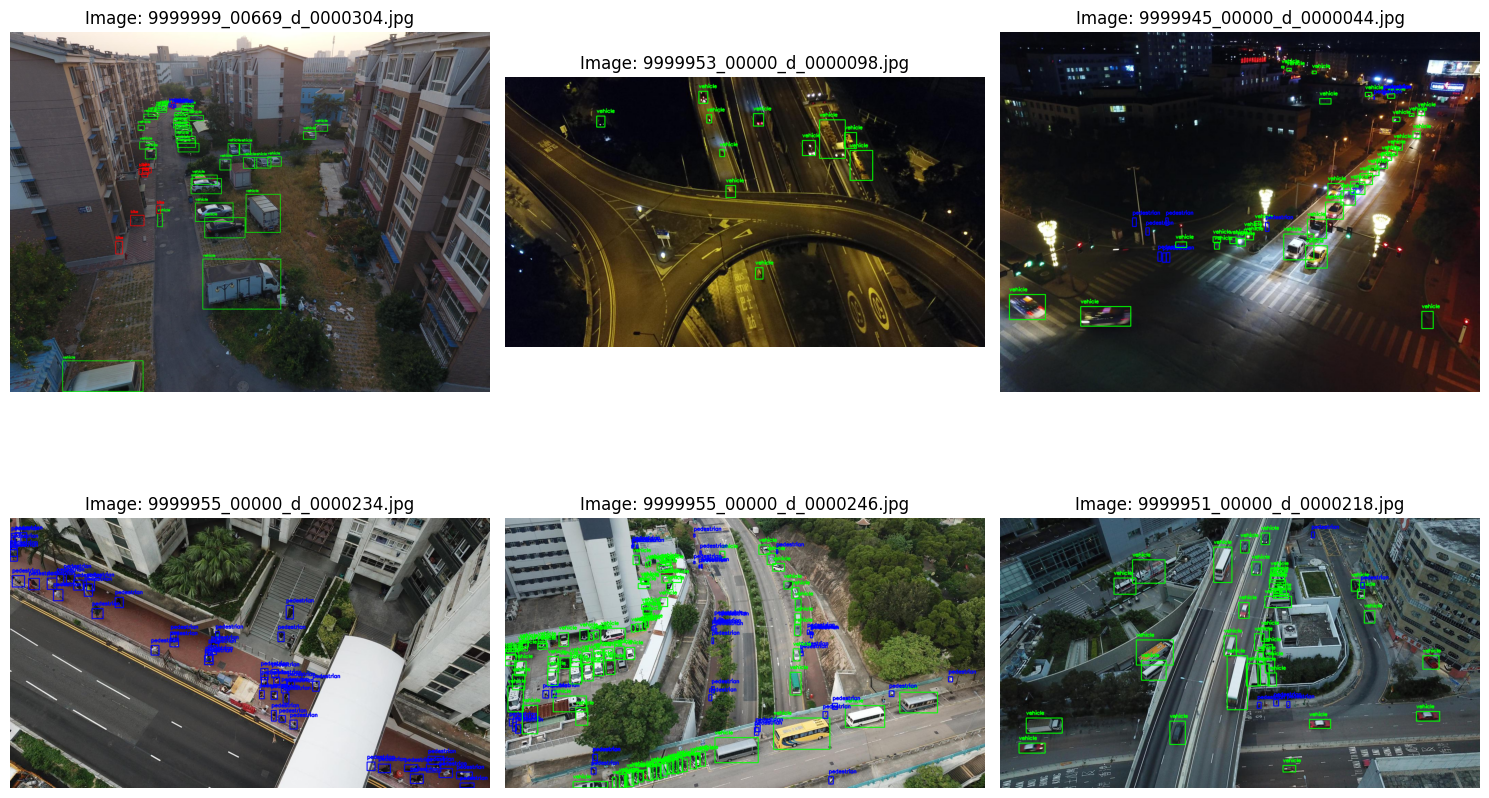

Saved to outputs/plots/


In [2]:
def draw_boxes(img_path, label_path):
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
                
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            
            x1 = int((x_center - width/2) * w)
            y1 = int((y_center - height/2) * h)
            x2 = int((x_center + width/2) * w)
            y2 = int((y_center + height/2) * h)
            
            color = COLORS[class_id]
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            
            label = CLASS_NAMES[class_id]
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_files = list(train_img_dir.glob('*.jpg'))
random.shuffle(img_files)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img_file = img_files[i]
    label_file = train_label_dir / f"{img_file.stem}.txt"
    
    img_with_boxes = draw_boxes(img_file, label_file)
    
    ax.imshow(img_with_boxes)
    ax.set_title(f"Image: {img_file.name}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/data_exploration_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to outputs/plots/")


=== Class distribution ===
        Class   Count
1     vehicle  218271
0  pedestrian   79337
2        bike   15292

=== Statistics ===
Object number/img: 48.35
Bbox average size (normalized): 0.001632
Very small objects (< 0.001): 209864 (67.1%)


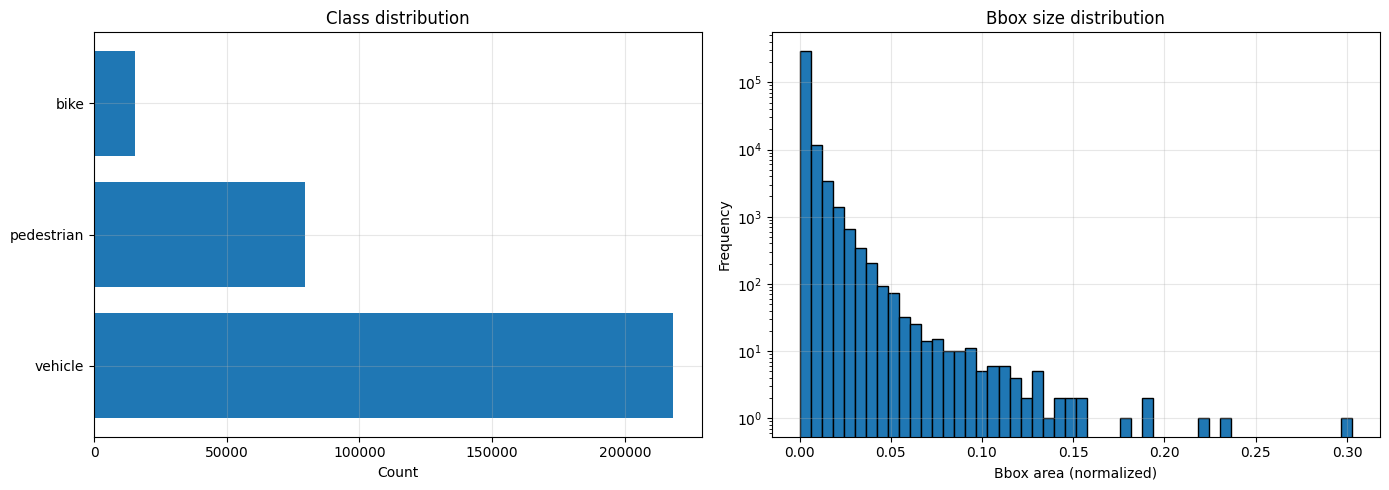

In [3]:
import pandas as pd

class_counts = {name: 0 for name in CLASS_NAMES}
bbox_sizes = []
num_objects_per_image = []

for label_file in train_label_dir.glob('*.txt'):
    num_objects = 0
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            
            class_id = int(parts[0])
            width, height = map(float, parts[3:5])
            
            class_counts[CLASS_NAMES[class_id]] += 1
            bbox_sizes.append(width * height)
            num_objects += 1
    
    num_objects_per_image.append(num_objects)

print("\n=== Class distribution ===")
df_classes = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_classes = df_classes.sort_values('Count', ascending=False)
print(df_classes)

print(f"\n=== Statistics ===")
print(f"Object number/img: {np.mean(num_objects_per_image):.2f}")
print(f"Bbox average size (normalized): {np.mean(bbox_sizes):.6f}")
print(f"Very small objects (< 0.001): {sum(1 for s in bbox_sizes if s < 0.001)} ({100*sum(1 for s in bbox_sizes if s < 0.001)/len(bbox_sizes):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(df_classes['Class'], df_classes['Count'])
axes[0].set_xlabel('Count')
axes[0].set_title('Class distribution')
axes[0].grid(alpha=0.3)

axes[1].hist(bbox_sizes, bins=50, edgecolor='black')
axes[1].set_xlabel('Bbox area (normalized)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Bbox size distribution')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/data_statistics.png', dpi=150, bbox_inches='tight')
plt.show()